# 03 - CNN interpretability: saliency heatmap quanh mutation

Notebook nay dung model CNN 9-channel da train trong notebook 02 de xem model hoc duoc gi:

- Saliency theo vi tri trong window `201 bp`
- Heatmap theo 9 channels: `ref A/C/G/T`, `alt A/C/G/T`, `mutation marker`
- So sanh vung gan center voi hai bien
- Xem vi du pathogenic/benign co score cao/thap

Luu y: saliency gradient la heuristic giai thich model, khong phai bang chung nhan qua sinh hoc.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

PROJECT_DIR = Path("/mnt/MyData/Bioinformatics/Project")
PROCESSED_DIR = PROJECT_DIR / "processed"
MODEL_DIR = PROJECT_DIR / "models"

X_PATH = PROCESSED_DIR / "X_ref_alt_marker_201.npy"
Y_PATH = PROCESSED_DIR / "y.npy"
METADATA_PATH = PROCESSED_DIR / "clinvar_training_metadata.parquet"
MODEL_PATH = MODEL_DIR / "clinvar_ref_alt_marker_cnn_demo_pytorch.pt"

for path in [X_PATH, Y_PATH, METADATA_PATH, MODEL_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

CHANNEL_NAMES = [
    "ref_A", "ref_C", "ref_G", "ref_T",
    "alt_A", "alt_C", "alt_G", "alt_T",
    "mutation_marker",
]
CENTER_INDEX = 100
POSITIONS = np.arange(-CENTER_INDEX, CENTER_INDEX + 1)

sns.set_theme(style="whitegrid")

## 1. Load data va model CNN

In [5]:
X = np.load(X_PATH, mmap_mode="r")
y = np.load(Y_PATH)
metadata_df = pd.read_parquet(METADATA_PATH)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"metadata shape: {metadata_df.shape}")
print(f"label counts: {dict(zip(*np.unique(y, return_counts=True)))}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

X shape: (460488, 201, 9)
y shape: (460488,)
metadata shape: (460488, 15)
label counts: {np.int8(0): np.int64(401054), np.int8(1): np.int64(59434)}
Device: cuda


In [6]:
class ClinVarCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(9, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)


# Checkpoint nay do notebook 02 tao trong project local. PyTorch 2.6 mac dinh weights_only=True,
# nhung file co them metadata NumPy nen can weights_only=False de load day du dict.
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model = ClinVarCNN().to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded model: {MODEL_PATH}")

Loaded model: /mnt/MyData/Bioinformatics/Project/models/clinvar_ref_alt_marker_cnn_demo_pytorch.pt


## 2. Tao lai test split va lay prediction

Dung cung split `RANDOM_STATE=42` voi notebook 02.

In [7]:
RANDOM_STATE = 42
indices = np.arange(len(y))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=RANDOM_STATE, stratify=y[temp_idx])


def predict_proba(indices, batch_size=2048):
    probs = []
    with torch.no_grad():
        for start in tqdm(range(0, len(indices), batch_size), desc="predict", unit="batch"):
            batch_idx = indices[start:start + batch_size]
            x_np = np.asarray(X[batch_idx]).transpose(0, 2, 1).copy()
            x = torch.from_numpy(x_np).float().to(DEVICE)
            logits = model(x)
            probs.append(torch.sigmoid(logits).detach().cpu().numpy())
    return np.concatenate(probs)


proba_test = predict_proba(test_idx)
pred_test = (proba_test >= 0.5).astype(np.int8)
y_test = y[test_idx]

print(f"test size: {len(test_idx):,}")
print(f"mean proba: {proba_test.mean():.4f}")

predict:   0%|          | 0/34 [00:00<?, ?batch/s]

test size: 69,074
mean proba: 0.3239


## 3. Chon subset de tinh saliency

Tinh gradient tren toan bo test set se ton thoi gian. Mac dinh lay mau can bang:

- 512 true pathogenic score cao
- 512 true benign score thap
- 512 false positive
- 512 false negative

Co the tang `N_PER_GROUP` neu muon heatmap on dinh hon.

In [8]:
N_PER_GROUP = 512

result_df = metadata_df.iloc[test_idx].copy()
result_df["row_index"] = test_idx
result_df["y_true"] = y_test
result_df["proba_pathogenic"] = proba_test
result_df["pred_label"] = pred_test

true_pos_df = result_df[(result_df["y_true"] == 1) & (result_df["pred_label"] == 1)].sort_values("proba_pathogenic", ascending=False).head(N_PER_GROUP)
true_neg_df = result_df[(result_df["y_true"] == 0) & (result_df["pred_label"] == 0)].sort_values("proba_pathogenic", ascending=True).head(N_PER_GROUP)
false_pos_df = result_df[(result_df["y_true"] == 0) & (result_df["pred_label"] == 1)].sort_values("proba_pathogenic", ascending=False).head(N_PER_GROUP)
false_neg_df = result_df[(result_df["y_true"] == 1) & (result_df["pred_label"] == 0)].sort_values("proba_pathogenic", ascending=True).head(N_PER_GROUP)

saliency_groups = {
    "true_pathogenic_high_score": true_pos_df,
    "true_benign_low_score": true_neg_df,
    "false_positive_high_score": false_pos_df,
    "false_negative_low_score": false_neg_df,
}

for name, df in saliency_groups.items():
    print(name, len(df))

true_pathogenic_high_score 512
true_benign_low_score 512
false_positive_high_score 512
false_negative_low_score 512


## 4. Saliency gradient

Saliency o day la:

`abs(d logit_pathogenic / d input)`

Gia tri cao nghia la thay doi input tai vi tri/channel do co anh huong manh den logit pathogenic.

In [9]:
def compute_saliency(row_indices, batch_size=256):
    all_saliency = []
    all_probs = []

    for start in tqdm(range(0, len(row_indices), batch_size), desc="saliency", unit="batch"):
        batch_idx = row_indices[start:start + batch_size]
        x_np = np.asarray(X[batch_idx]).transpose(0, 2, 1).copy()
        x = torch.from_numpy(x_np).float().to(DEVICE)
        x.requires_grad_(True)

        model.zero_grad(set_to_none=True)
        logits = model(x)
        logits.sum().backward()

        saliency = x.grad.detach().abs().cpu().numpy()
        probs = torch.sigmoid(logits).detach().cpu().numpy()

        # Convert back to (batch, length, channels).
        all_saliency.append(saliency.transpose(0, 2, 1))
        all_probs.append(probs)

    return np.concatenate(all_saliency), np.concatenate(all_probs)


saliency_by_group = {}
for name, df in saliency_groups.items():
    row_indices = df["row_index"].to_numpy()
    saliency, probs = compute_saliency(row_indices)
    saliency_by_group[name] = {
        "saliency": saliency,
        "probs": probs,
        "rows": df,
    }
    print(name, saliency.shape)

saliency:   0%|          | 0/2 [00:00<?, ?batch/s]

true_pathogenic_high_score (512, 201, 9)


saliency:   0%|          | 0/2 [00:00<?, ?batch/s]

true_benign_low_score (512, 201, 9)


saliency:   0%|          | 0/2 [00:00<?, ?batch/s]

false_positive_high_score (512, 201, 9)


saliency:   0%|          | 0/2 [00:00<?, ?batch/s]

false_negative_low_score (512, 201, 9)


## 5. Heatmap saliency trung binh theo channel va vi tri

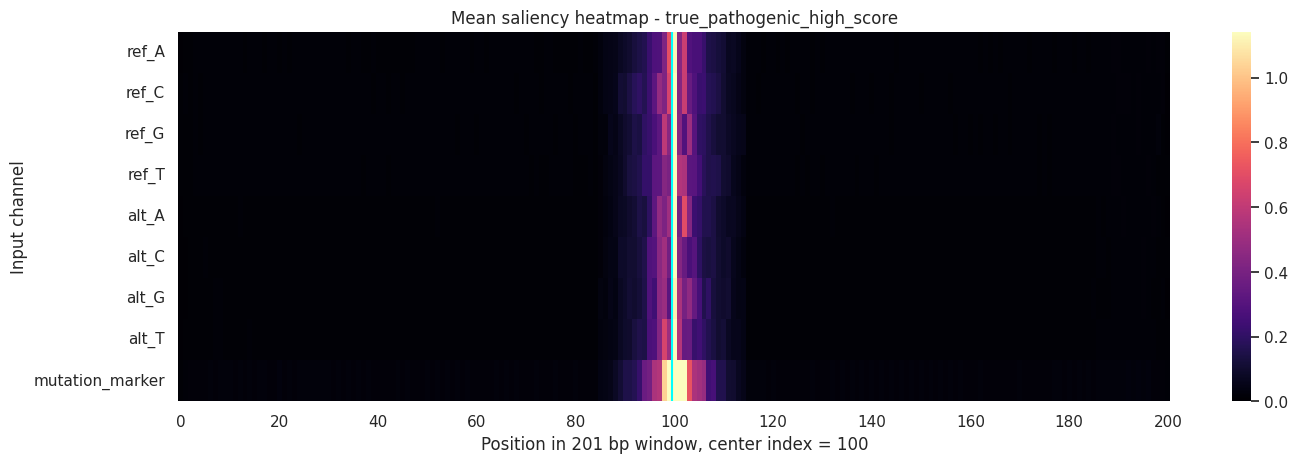

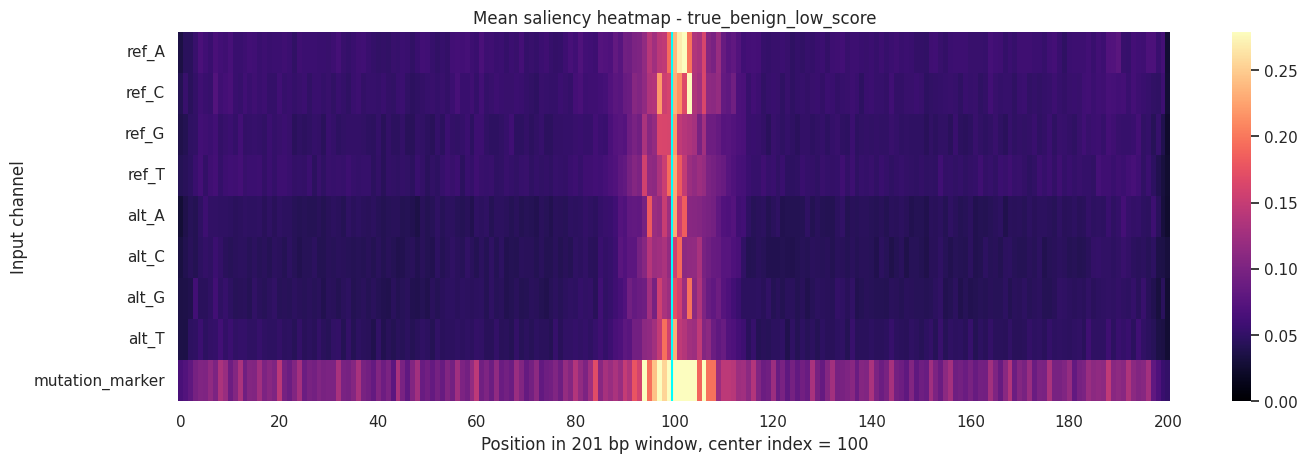

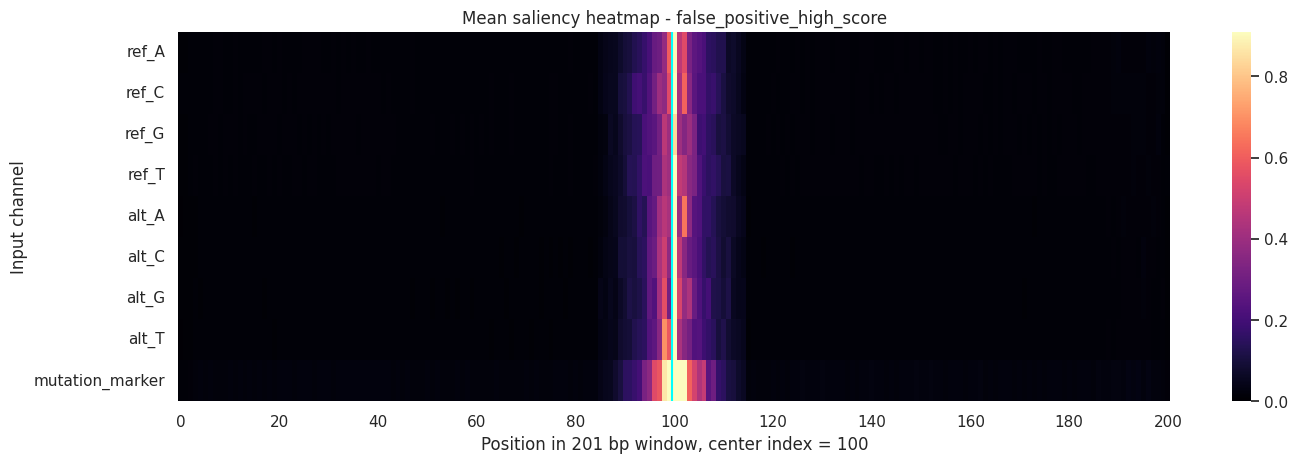

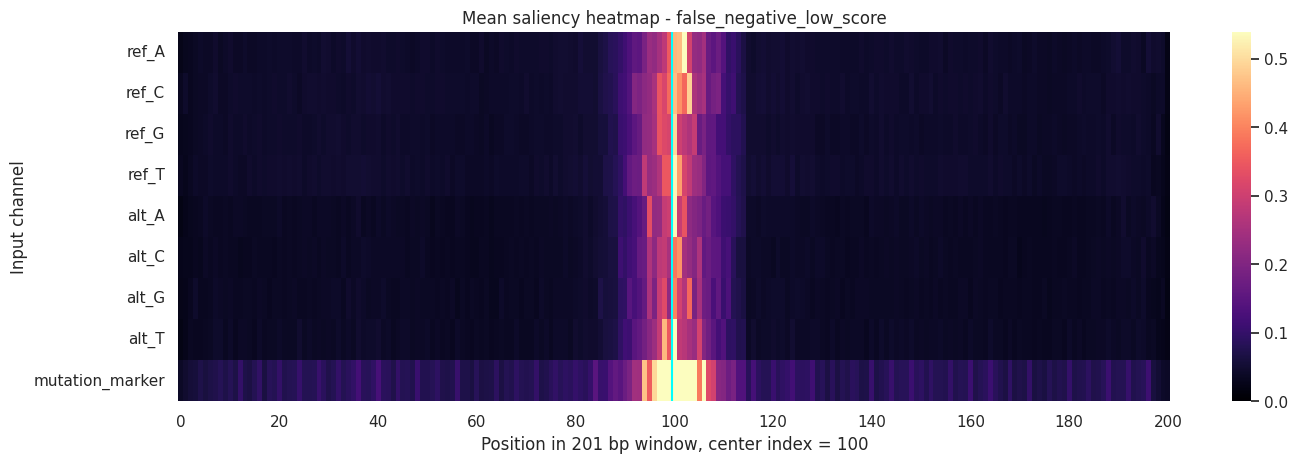

In [10]:
def plot_group_heatmap(group_name, clip_quantile=0.995):
    saliency = saliency_by_group[group_name]["saliency"]
    mean_saliency = saliency.mean(axis=0)  # (201, 9)
    plot_matrix = mean_saliency.T
    vmax = np.quantile(plot_matrix, clip_quantile)

    plt.figure(figsize=(16, 4.8))
    ax = sns.heatmap(
        plot_matrix,
        cmap="magma",
        vmin=0,
        vmax=vmax,
        xticklabels=20,
        yticklabels=CHANNEL_NAMES,
    )
    ax.axvline(CENTER_INDEX, color="cyan", linewidth=1.5)
    ax.set_title(f"Mean saliency heatmap - {group_name}")
    ax.set_xlabel("Position in 201 bp window, center index = 100")
    ax.set_ylabel("Input channel")
    plt.show()


for group_name in saliency_by_group:
    plot_group_heatmap(group_name)

## 6. Saliency theo khoang cach toi mutation center

Gop saliency qua channel de xem model chu y gan center hay ngoai bien.

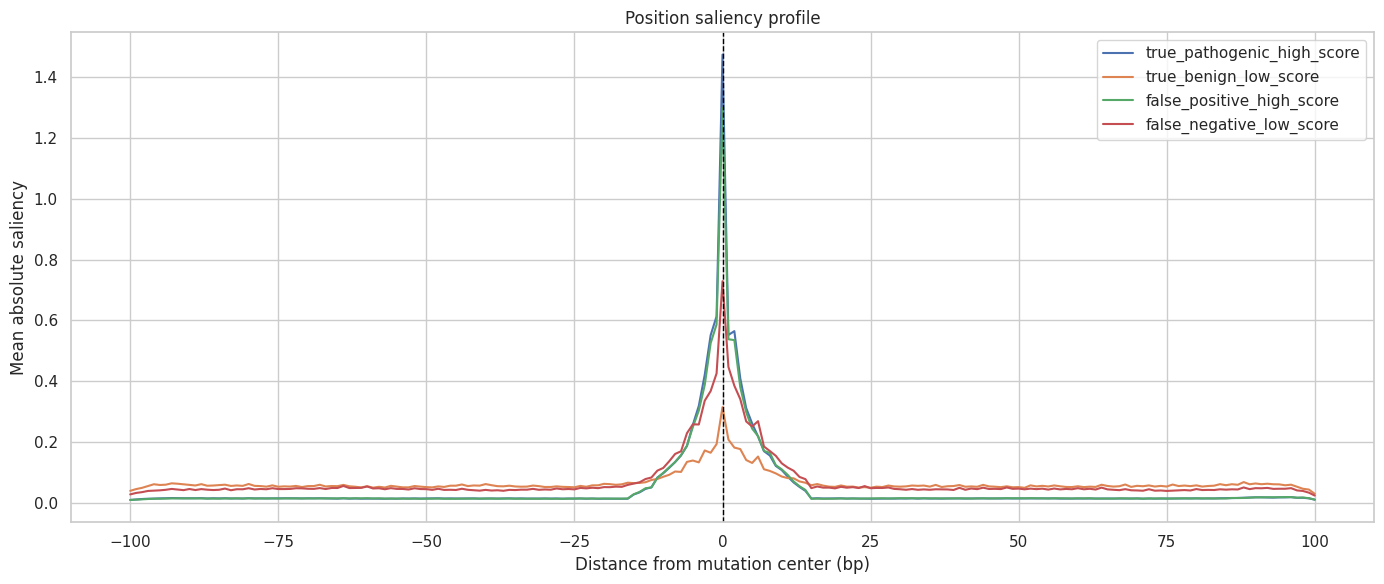

In [11]:
plt.figure(figsize=(14, 6))

position_profiles = {}
for group_name, values in saliency_by_group.items():
    saliency = values["saliency"]
    profile = saliency.mean(axis=(0, 2))  # mean over samples and channels -> length 201
    position_profiles[group_name] = profile
    plt.plot(POSITIONS, profile, label=group_name)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Distance from mutation center (bp)")
plt.ylabel("Mean absolute saliency")
plt.title("Position saliency profile")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def summarize_center_vs_edges(profile):
    abs_pos = np.abs(POSITIONS)
    return {
        "center_±1": profile[abs_pos <= 1].mean(),
        "center_±5": profile[abs_pos <= 5].mean(),
        "center_±10": profile[abs_pos <= 10].mean(),
        "center_±20": profile[abs_pos <= 20].mean(),
        "middle_21_to_50": profile[(abs_pos >= 21) & (abs_pos <= 50)].mean(),
        "edge_80_to_100": profile[abs_pos >= 80].mean(),
        "center10_over_edge": profile[abs_pos <= 10].mean() / (profile[abs_pos >= 80].mean() + 1e-12),
    }

center_edge_df = pd.DataFrame({
    group: summarize_center_vs_edges(profile)
    for group, profile in position_profiles.items()
}).T

center_edge_df

,center_±1,center_±5,center_±10,center_±20,middle_21_to_50,edge_80_to_100,center10_over_edge
true_pathogenic_high_score,0.880382,0.521551,0.342698,0.191032,0.013871,0.014837,23.097818
true_benign_low_score,0.238545,0.177611,0.143778,0.105204,0.054100,0.056559,2.542099
false_positive_high_score,0.808216,0.486233,0.325249,0.182427,0.013839,0.014634,22.225271
false_negative_low_score,0.533983,0.369629,0.275414,0.173938,0.045017,0.042307,6.509921


## 7. Channel importance

Xem model nhay voi ref channels, alt channels, hay mutation marker.

In [13]:
channel_importance_rows = []
for group_name, values in saliency_by_group.items():
    saliency = values["saliency"]
    channel_mean = saliency.mean(axis=(0, 1))
    row = {channel: value for channel, value in zip(CHANNEL_NAMES, channel_mean)}
    row["ref_total"] = channel_mean[:4].sum()
    row["alt_total"] = channel_mean[4:8].sum()
    row["marker"] = channel_mean[8]
    row["alt_over_ref"] = row["alt_total"] / (row["ref_total"] + 1e-12)
    row["group"] = group_name
    channel_importance_rows.append(row)

channel_importance_df = pd.DataFrame(channel_importance_rows).set_index("group")
channel_importance_df

,ref_A,ref_C,ref_G,ref_T,alt_A,alt_C,alt_G,alt_T,mutation_marker,ref_total,alt_total,marker,alt_over_ref
group,,,,,,,,,,,,,
true_pathogenic_high_score,0.045655,0.050282,0.045403,0.048167,0.043905,0.041107,0.042943,0.044462,0.090046,0.189508,0.172416,0.090046,0.909812
true_benign_low_score,0.066289,0.064266,0.058662,0.060849,0.052807,0.051360,0.052251,0.055522,0.123532,0.250067,0.211939,0.123532,0.847528
false_positive_high_score,0.043722,0.046435,0.042472,0.045173,0.044119,0.040355,0.041263,0.044242,0.088451,0.177802,0.169979,0.088451,0.956006
false_negative_low_score,0.066276,0.068701,0.063164,0.066280,0.057221,0.056433,0.056858,0.060240,0.141860,0.264420,0.230752,0.141860,0.872672


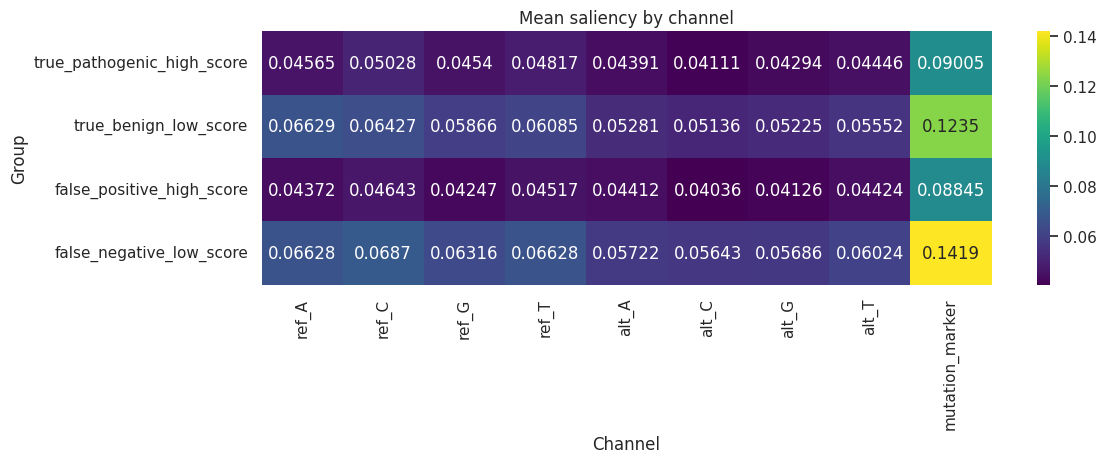

In [14]:
plt.figure(figsize=(12, 4.8))
plot_df = channel_importance_df[CHANNEL_NAMES]
sns.heatmap(plot_df, cmap="viridis", annot=True, fmt=".4g")
plt.title("Mean saliency by channel")
plt.xlabel("Channel")
plt.ylabel("Group")
plt.tight_layout()
plt.show()

## 8. Xem mot variant cu the

Cell nay ve heatmap saliency cho mot variant rieng le. Doi `EXAMPLE_GROUP` va `EXAMPLE_RANK` de xem mau khac.

saliency:   0%|          | 0/1 [00:00<?, ?batch/s]

GeneSymbol                                                           PCCA
ClinicalSignificance                                    Likely pathogenic
Y                                                                       1
proba_pathogenic                                                  0.99854
pred_label                                                              1
Chromosome                                                             13
PositionVCF                                                     100449306
ReferenceAlleleVCF                                                      G
AlternateAlleleVCF                                                      T
ReviewStatus            criteria provided, multiple submitters, no con...
Name: 301116, dtype: object


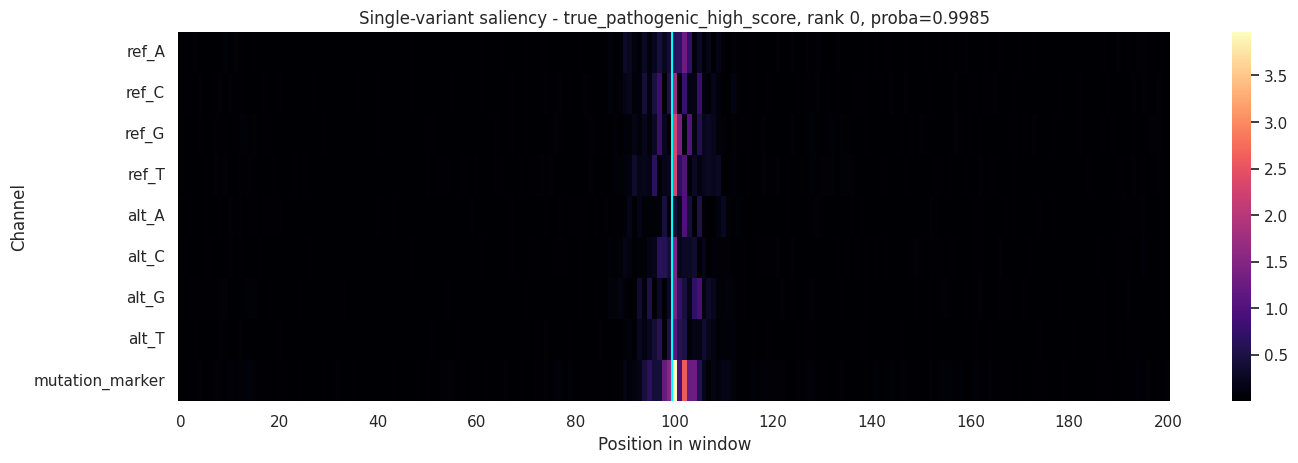

In [15]:
EXAMPLE_GROUP = "true_pathogenic_high_score"
EXAMPLE_RANK = 0

example_row = saliency_by_group[EXAMPLE_GROUP]["rows"].iloc[EXAMPLE_RANK]
example_idx = int(example_row["row_index"])
example_x = np.asarray(X[example_idx])
example_saliency, example_prob = compute_saliency(np.array([example_idx]), batch_size=1)
example_saliency = example_saliency[0]

print(example_row[[
    "GeneSymbol", "ClinicalSignificance", "Y", "proba_pathogenic", "pred_label",
    "Chromosome", "PositionVCF", "ReferenceAlleleVCF", "AlternateAlleleVCF", "ReviewStatus"
]])

plt.figure(figsize=(16, 4.8))
sns.heatmap(
    example_saliency.T,
    cmap="magma",
    xticklabels=20,
    yticklabels=CHANNEL_NAMES,
)
plt.axvline(CENTER_INDEX, color="cyan", linewidth=1.5)
plt.title(f"Single-variant saliency - {EXAMPLE_GROUP}, rank {EXAMPLE_RANK}, proba={float(example_prob[0]):.4f}")
plt.xlabel("Position in window")
plt.ylabel("Channel")
plt.show()

## 9. Luu bang tom tat interpretability

In [16]:
OUTPUT_DIR = PROCESSED_DIR / "interpretability"
OUTPUT_DIR.mkdir(exist_ok=True)

center_edge_path = OUTPUT_DIR / "cnn_saliency_center_vs_edges.parquet"
channel_importance_path = OUTPUT_DIR / "cnn_saliency_channel_importance.parquet"

center_edge_df.to_parquet(center_edge_path, engine="pyarrow")
channel_importance_df.to_parquet(channel_importance_path, engine="pyarrow")

print(f"Saved: {center_edge_path}")
print(f"Saved: {channel_importance_path}")

Saved: /mnt/MyData/Bioinformatics/Project/processed/interpretability/cnn_saliency_center_vs_edges.parquet
Saved: /mnt/MyData/Bioinformatics/Project/processed/interpretability/cnn_saliency_channel_importance.parquet
